# Preprocessing Data
## Import Library

In [18]:
# Import semua library yang diperlukan
import pandas as pd
import numpy as np
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Preprocessing
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Set style
plt.style.use('default')
sns.set_palette("tab10")

## Muat dan Siapkan Data

In [ ]:
train_path = 'ECG200/ECG200_TRAIN.arff'
test_path = 'ECG200/ECG200_TEST.arff'

data_train, _ = arff.loadarff(train_path)
data_test, _ = arff.loadarff(test_path)

df_train = pd.DataFrame(data_train)
df_test = pd.DataFrame(data_test)

X_train = df_train.iloc[:, :-1].values  # 96 kolom
y_train = df_train['target'].apply(lambda x: 1 if x == b'1' else -1).values

X_test = df_test.iloc[:, :-1].values
y_test = df_test['target'].apply(lambda x: 1 if x == b'1' else -1).values

print(f"Data latih: {X_train.shape}, Label: {y_train.shape}")
print(f"Data uji: {X_test.shape}, Label: {y_test.shape}")

Data latih: (100, 96), Label: (100,)
Data uji: (100, 96), Label: (100,)


## Cek Distribusi Kelas Sebelum Balancing

📉 Distribusi kelas SEBELUM balancing:
  Kelas -1 (Abnormal): 31
  Kelas  1 (Normal)  : 69


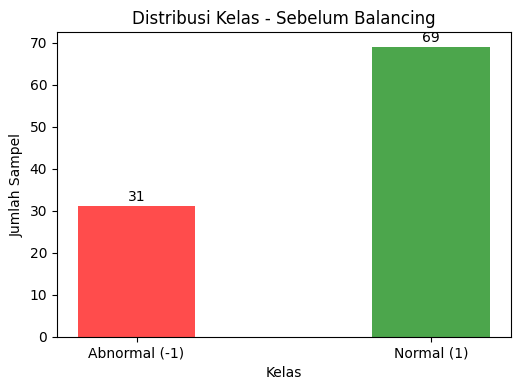

In [ ]:
counter_before = Counter(y_train)
print("📉 Distribusi kelas SEBELUM balancing:")
print(f"  Kelas -1 (Abnormal): {counter_before[-1]}")
print(f"  Kelas  1 (Normal)  : {counter_before[1]}")

# Visualisasi sebelum
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
bars = plt.bar(counter_before.keys(), counter_before.values(), color=['red', 'green'], alpha=0.7)
plt.title('Distribusi Kelas - Sebelum Balancing', fontsize=12)
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks([-1, 1], ['Abnormal (-1)', 'Normal (1)'])
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(int(bar.get_height())), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Normalisasi Data

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data telah dinormalisasi.")

✅ Data telah dinormalisasi.


## Simpan Scaler

In [ ]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.preprocessing import StandardScaler
import joblib

# Muat data latih mentah
train_path = 'ECG200/ECG200_TRAIN.arff'
data_train, _ = arff.loadarff(train_path)
df_train = pd.DataFrame(data_train)

X_train_raw = df_train.iloc[:, :-1].values

# Fit scaler
scaler = StandardScaler()
scaler.fit(X_train_raw)

# Simpan
joblib.dump(scaler, 'ECG200/scaler.pkl')
print("✅ Scaler berhasil disimpan!")

✅ Scaler berhasil disimpan!


##  Lakukan Balancing dengan SMOTE

In [22]:
# Cek apakah data imbalance
if counter_before[-1] != counter_before[1]:
    print("🔧 Data tidak seimbang → lakukan balancing dengan SMOTE...")
    
    # SMOTE (aplikasikan hanya pada data latih!)
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
    
    print(f"✅ Setelah balancing: {X_train_bal.shape[0]} sampel")
else:
    print("✅ Data sudah seimbang. Lewati SMOTE.")
    X_train_bal, y_train_bal = X_train_scaled, y_train

# Simpan hasil balancing
counter_after = Counter(y_train_bal)

🔧 Data tidak seimbang → lakukan balancing dengan SMOTE...
✅ Setelah balancing: 138 sampel


## Visualisasi Distribusi Setelah Balancing

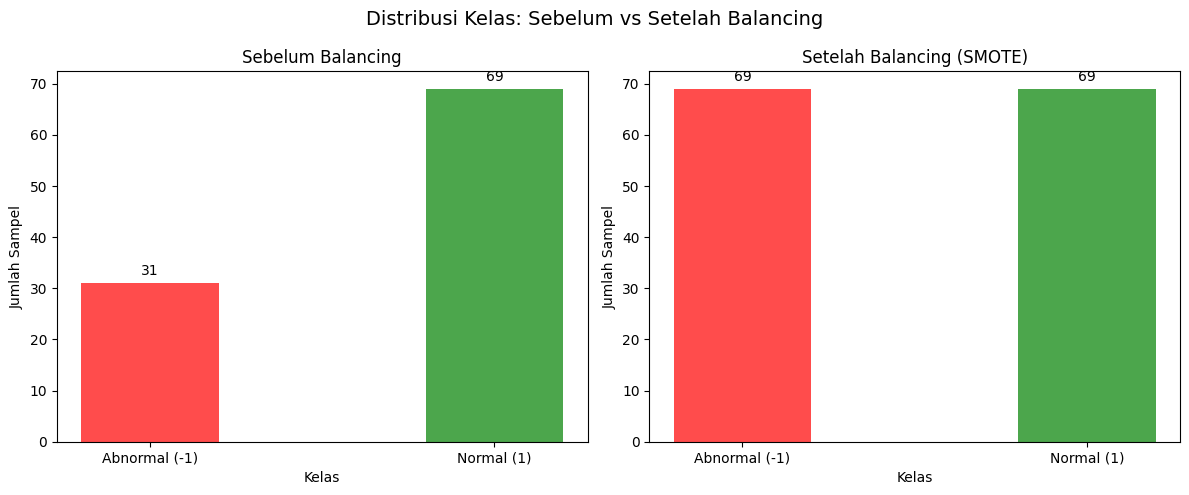

In [23]:
# Visualisasi sebelum & sesudah
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Sebelum
ax[0].bar(counter_before.keys(), counter_before.values(), color=['red', 'green'], alpha=0.7)
ax[0].set_title('Sebelum Balancing', fontsize=12)
ax[0].set_xlabel('Kelas')
ax[0].set_ylabel('Jumlah Sampel')
ax[0].set_xticks([-1, 1])
ax[0].set_xticklabels(['Abnormal (-1)', 'Normal (1)'])
for k, v in counter_before.items():
    ax[0].text(k, v + 1, str(v), ha='center', va='bottom')

# Sesudah
ax[1].bar(counter_after.keys(), counter_after.values(), color=['red', 'green'], alpha=0.7)
ax[1].set_title('Setelah Balancing (SMOTE)', fontsize=12)
ax[1].set_xlabel('Kelas')
ax[1].set_ylabel('Jumlah Sampel')
ax[1].set_xticks([-1, 1])
ax[1].set_xticklabels(['Abnormal (-1)', 'Normal (1)'])
for k, v in counter_after.items():
    ax[1].text(k, v + 1, str(v), ha='center', va='bottom')

plt.suptitle('Distribusi Kelas: Sebelum vs Setelah Balancing', fontsize=14)
plt.tight_layout()
plt.show()

## Simpan Data Siap Model

In [25]:
# Simpan ke file .npy
np.save('ECG200/X_train_bal.npy', X_train_final)
np.save('ECG200/y_train_bal.npy', y_train_final)
np.save('ECG200/X_test_bal.npy', X_test_final)
np.save('ECG200/y_test_bal.npy', y_test_final)

print("✅ Data berhasil disimpan sebagai .npy di folder ECG200/")

✅ Data berhasil disimpan sebagai .npy di folder ECG200/
